# Sleep Health and Lifestyle Analysis

This notebook analyzes the Sleep Health and Lifestyle dataset, exploring relationships between various health and lifestyle factors and sleep quality. The analysis includes data cleaning, preprocessing, and visualizations.

## 1. Import Required Libraries

We start by importing the necessary Python libraries for data analysis and visualization.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Load the Sleep Health and Lifestyle dataset. Ensure the CSV file is in the same directory as this notebook.

In [41]:
df = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 3. Data Cleaning & Preprocessing

Prepare the data for analysis by handling missing values, consolidating categories, and extracting features.

In [42]:
# Fill NaN in Sleep Disorder with 'None'
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Consolidate BMI categories (merge Normal Weight into Normal)
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")

# Split Blood Pressure into Systolic and Diastolic
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


## 4. Visual Analysis

Explore the relationships between variables using visualizations.

In [33]:
sns.set_theme(style="whitegrid")

### 4.1 Correlation Heatmap

Visualize the correlation between numeric variables to identify potential relationships.

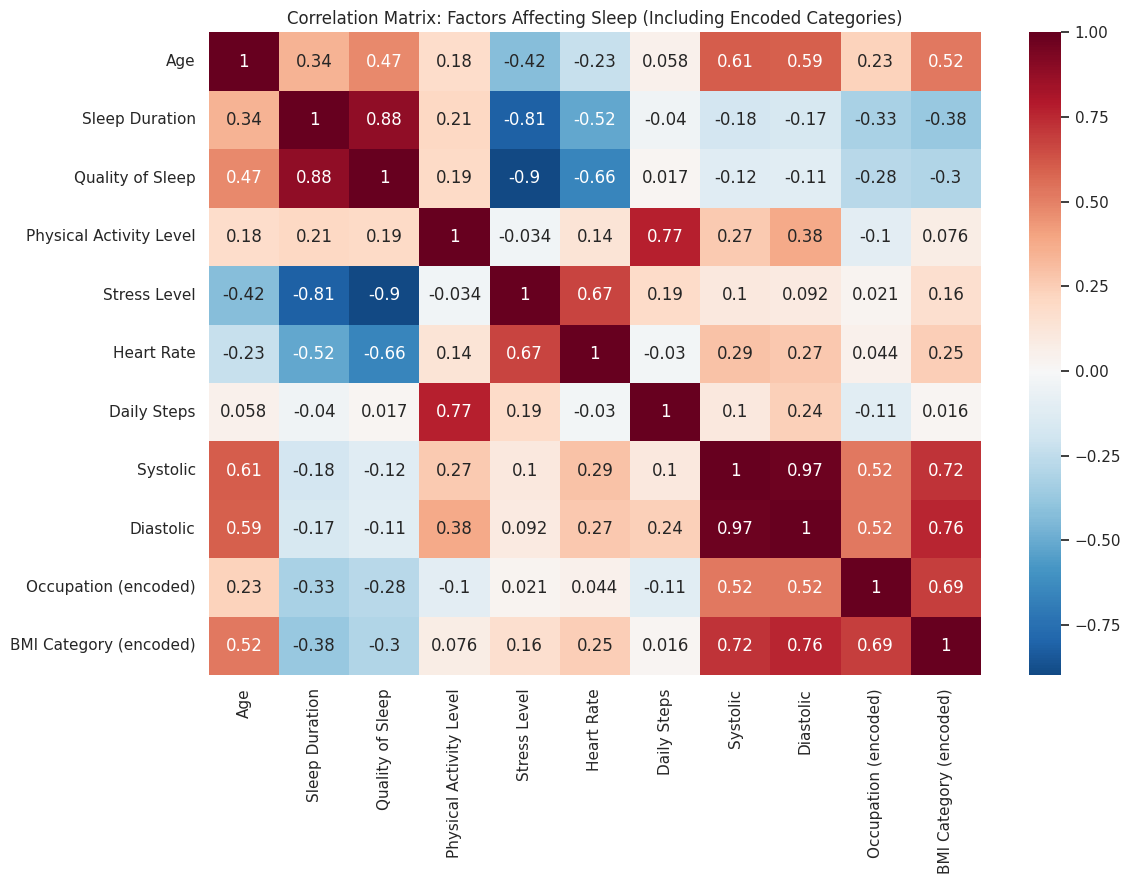

In [43]:
plt.figure(figsize=(12, 9))

numeric_cols = df.select_dtypes(include=["number"]).drop(columns=["Person ID"])
heatmap_df = numeric_cols.copy()
heatmap_df["Occupation (encoded)"] = df["Occupation"].astype("category").cat.codes
heatmap_df["BMI Category (encoded)"] = df["BMI Category"].astype("category").cat.codes

sns.heatmap(heatmap_df.corr(), annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Matrix: Factors Affecting Sleep (Including Encoded Categories)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

### 4.2 Sleep Duration vs Quality

Examine the relationship between sleep duration and quality of sleep.

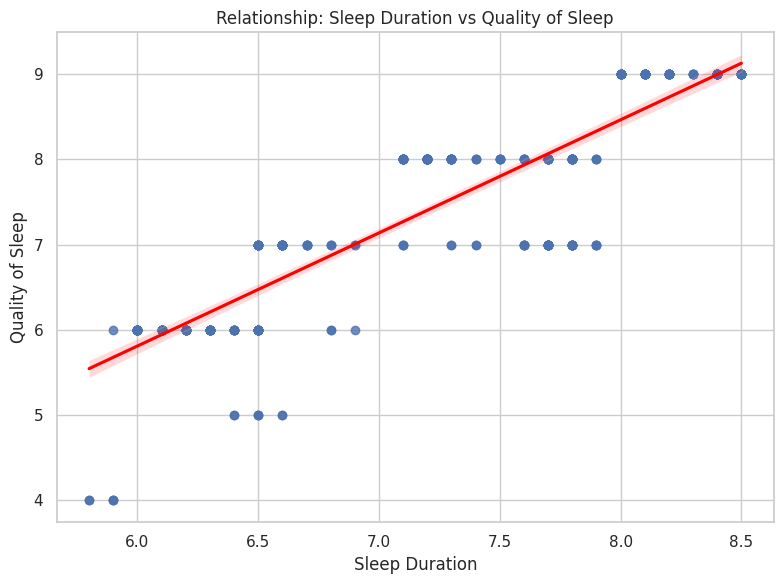

In [35]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, x="Sleep Duration", y="Quality of Sleep", line_kws={"color": "red"}
)
plt.title("Relationship: Sleep Duration vs Quality of Sleep")
plt.tight_layout()
plt.savefig("duration_vs_quality.png")
plt.show()

### 4.3 Stress Level vs Quality of Sleep

Analyze how stress level affects the quality of sleep using a boxplot.

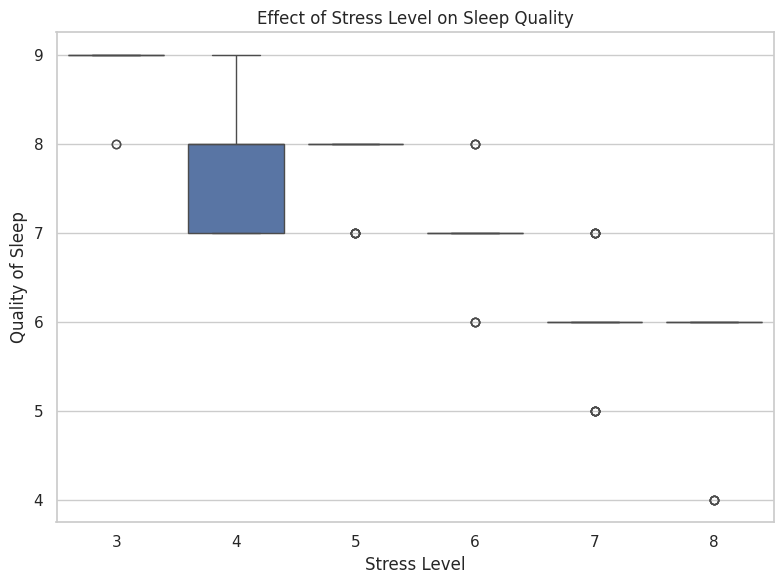

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Stress Level", y="Quality of Sleep")
plt.title("Effect of Stress Level on Sleep Quality")
plt.tight_layout()
plt.savefig("stress_vs_quality.png")
plt.show()

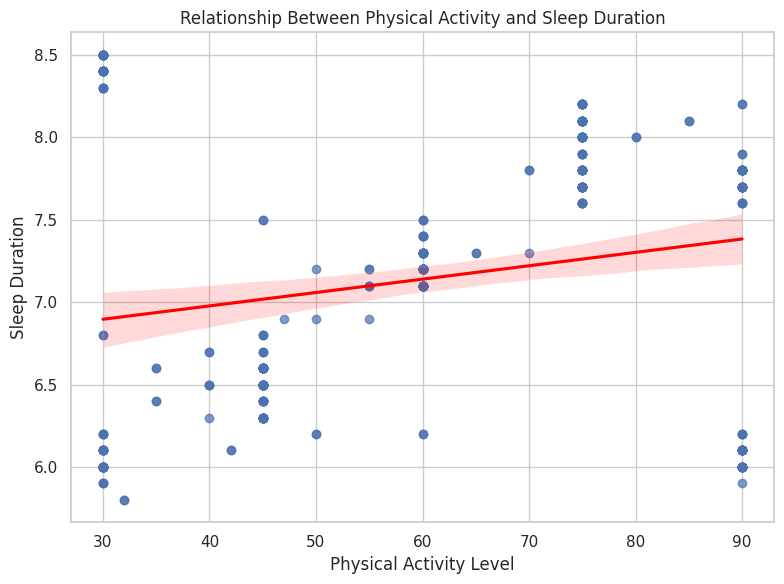

In [37]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="Physical Activity Level", y="Sleep Duration", scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("Relationship Between Physical Activity and Sleep Duration")
plt.xlabel("Physical Activity Level")
plt.ylabel("Sleep Duration")
plt.tight_layout()
plt.savefig("physical_activity_vs_sleep_duration.png")
plt.show()

### 4.5 Relationship Between Physical Activity and Sleep Duration

Explore how physical activity level is related to sleep duration using a regression scatter plot.

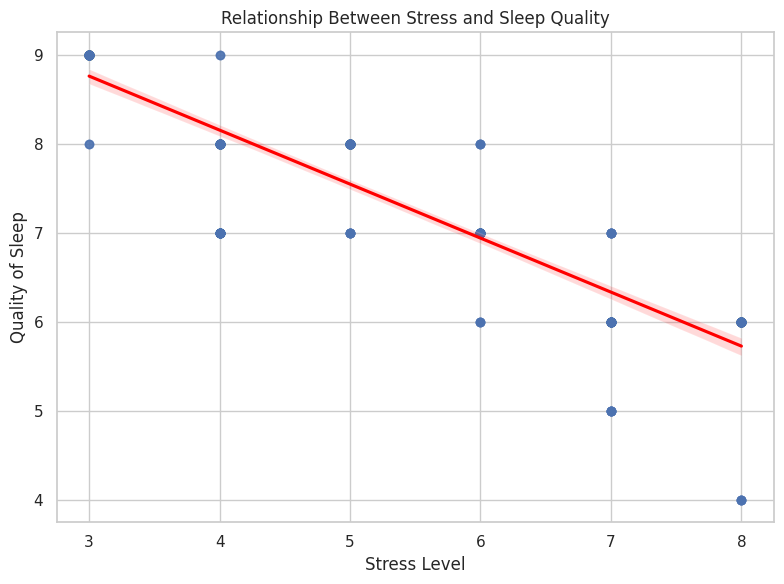

In [38]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="Stress Level", y="Quality of Sleep", scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("Relationship Between Stress and Sleep Quality")
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.tight_layout()
plt.savefig("stress_vs_sleep_quality.png")
plt.show()

### 4.4 Relationship Between Stress and Sleep Quality

Explore how stress level is related to sleep quality using a regression scatter plot.

### 4.6 Average Quality of Sleep by Occupation

Compare the average quality of sleep across different occupations.

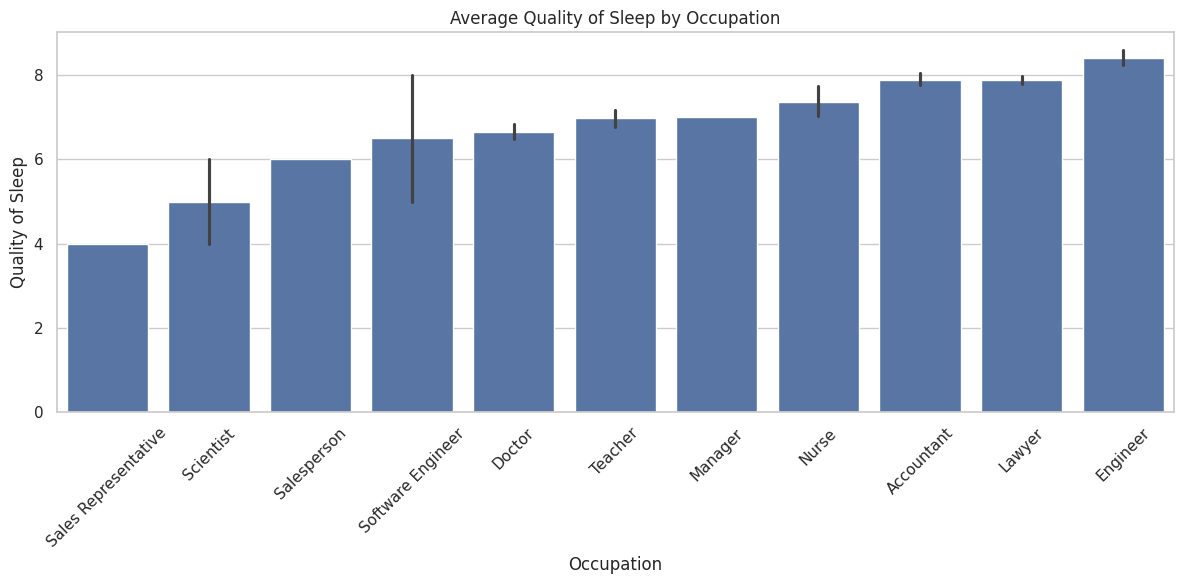

In [39]:
plt.figure(figsize=(12, 6))
occ_order = df.groupby("Occupation")["Quality of Sleep"].mean().sort_values().index
sns.barplot(data=df, x="Occupation", y="Quality of Sleep", order=occ_order)
plt.xticks(rotation=45)
plt.title("Average Quality of Sleep by Occupation")
plt.tight_layout()
plt.savefig("occupation_quality.png")
plt.show()

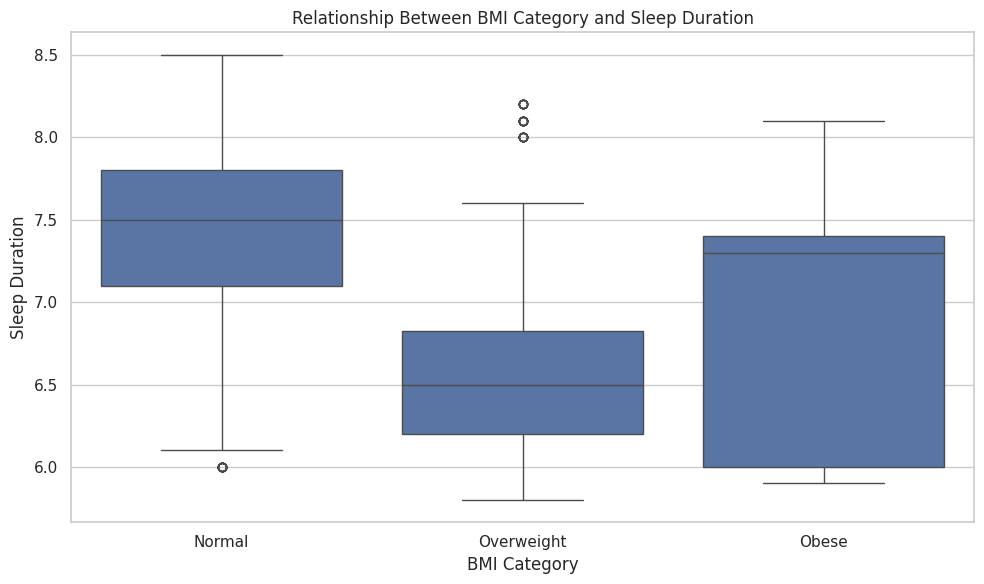

In [44]:
plt.figure(figsize=(10, 6))
order = ["Normal", "Overweight", "Obese"]
sns.boxplot(data=df, x="BMI Category", y="Sleep Duration", order=order)
plt.title("Relationship Between BMI Category and Sleep Duration")
plt.xlabel("BMI Category")
plt.ylabel("Sleep Duration")
plt.tight_layout()
plt.savefig("bmi_vs_sleep_duration.png")
plt.show()

### 4.7 Relationship Between BMI Category and Sleep Duration

Compare sleep duration across BMI categories to see how body weight category relates to sleep patterns.

---

This concludes the main visual analysis of the Sleep Health and Lifestyle dataset. You can further explore the data by analyzing other variables or creating additional visualizations as needed.